Librerías usadas

In [1]:


from kagglehub import dataset_download
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix



funcion para repartir los datos de entrenamiento en varios  arrays

In [ ]:
import numpy as np

def split_dataset(X, y, n_splits=2, shuffle=True, random_state=42):
    """
    Divide X e y en n_splits partes.

    Retorna:
        lista de tuplas: [(X_part1, y_part1), (X_part2, y_part2), ...]
    """
    if n_splits < 2:
        raise ValueError("n_splits debe ser >= 2")
    if len(X) != len(y):
        raise ValueError("X e y deben tener la misma cantidad de filas")

    n = len(X)
    indices = np.arange(n)

    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    # Índices divididos en partes (lo más balanceadas posible)
    split_indices = np.array_split(indices, n_splits)

    # Construir salida
    parts = []
    for idx in split_indices:
        parts.append((X[idx], y[idx]))
    return parts

1. CARGA Y PREPARACIÓN DE DATOS

In [2]:
print("Descargando dataset...")
path = dataset_download("oddrationale/mnist-in-csv")

train_df = pd.read_csv(path + "/mnist_train.csv")
test_df = pd.read_csv(path + "/mnist_test.csv")

print(train_df.shape)
print(train_df)
train_df.head()

# Separar características (X) y etiquetas (y)
X_train = train_df.iloc[:, 1:].values  # 60000 imágenes de 784 píxeles (28x28)
y_train = train_df.iloc[:, 0].values   # 60000 etiquetas (0-9)
X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values

# Normalizar: los píxeles van de 0-255, los llevamos a 0-1
# Esto ayuda a que los gradientes no exploten y el entrenamiento sea estable
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"X_train shape: {X_train.shape}")  # (60000, 784)
print(f"y_train shape: {y_train.shape}")  # (60000,)
print(f"X_test shape: {X_test.shape}")     # (10000, 784)
print(f"y_test shape: {y_test.shape}")     # (10000,)

Descargando dataset...
Using Colab cache for faster access to the 'mnist-in-csv' dataset.
(60000, 785)
       label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0          5    0    0    0    0    0    0    0    0    0  ...      0      0   
1          0    0    0    0    0    0    0    0    0    0  ...      0      0   
2          4    0    0    0    0    0    0    0    0    0  ...      0      0   
3          1    0    0    0    0    0    0    0    0    0  ...      0      0   
4          9    0    0    0    0    0    0    0    0    0  ...      0      0   
...      ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...    ...    ...   
59995      8    0    0    0    0    0    0    0    0    0  ...      0      0   
59996      3    0    0    0    0    0    0    0    0    0  ...      0      0   
59997      5    0    0    0    0    0    0    0    0    0  ...      0      0   
59998      6    0    0    0    0    0    0    0    0    0  ...      0      0   
59999      8    0

2. ARQUITECTURA DE LA RED NEURONAL

In [3]:


# Capa de entrada: 784 neuronas (28x28 píxeles)
# Capa oculta 1: 128 neuronas
# Capa oculta 2: 64 neuronas
# Capa de salida: 10 neuronas (uno por cada dígito 0-9)

# Hiperparámetros
INPUT_SIZE = 784      # 28 * 28
HIDDEN_SIZE = 10    # Primera capa oculta
OUTPUT_SIZE = 10      # Dígitos 0-9
LEARNING_RATE = 0.05  # Qué tan grandes son los pasos del gradiente
EPOCHS = 500           # Cuántas veces ve todo el dataset



3. INICIALIZACIÓN DE PESOS Y SESGOS

In [4]:
# np.random.seed(42)  # Para reproducibilidad

# Capa 1: Entrada (784) → Oculta (HIDDEN_SIZE)
# Cada fila corresponde a una entrada, cada columna a una neurona de la capa oculta
w1 = np.random.randn(INPUT_SIZE, HIDDEN_SIZE) * 0.01
b1 = np.zeros((1, HIDDEN_SIZE))

# Capa 2: Oculta → Salida (10 dígitos)
# Cada fila corresponde a una neurona de la capa oculta, cada columna a una neurona de salida
w2 = np.random.randn(HIDDEN_SIZE, OUTPUT_SIZE) * 0.01
b2 = np.zeros((1, OUTPUT_SIZE))

print(f"Pesos w1: {w1.shape}, b1: {b1.shape}")
print(f"Pesos w2: {w2.shape}, b2: {b2.shape}")

print(f"Primeros 5 pesos w1:\n{w1[:5]}")
print(f"Primeros 5 pesos w2:\n{w2[:5]}")

Pesos w1: (784, 10), b1: (1, 10)
Pesos w2: (10, 10), b2: (1, 10)
Primeros 5 pesos w1:
[[-0.00268034  0.00196381 -0.00108547  0.00852411 -0.00998024  0.00597839
  -0.01978558 -0.01789282  0.00753127  0.00923073]
 [-0.00261855  0.01055944 -0.00497803  0.03140238 -0.00850227 -0.01549011
   0.00479916 -0.00456327  0.00883296 -0.02457986]
 [ 0.00636759  0.00594558  0.0122396  -0.01163394  0.00815869 -0.00168011
  -0.01073673 -0.00687322  0.00695001 -0.00642694]
 [ 0.00685159 -0.01616634  0.01199151  0.00184449  0.02145157  0.02081521
   0.00929914  0.00369754  0.01460557 -0.01525253]
 [ 0.00926846  0.00095814  0.01767021  0.00379434 -0.01154463  0.00019041
  -0.02681774 -0.0076293  -0.00676717  0.00274111]]
Primeros 5 pesos w2:
[[ 1.69250121e-03 -1.28674487e-02 -6.78007092e-03 -9.83424461e-05
   7.28934015e-04  1.96260112e-03 -2.54210039e-03 -6.07137883e-03
   1.64038179e-03  6.43376686e-03]
 [-2.76503456e-02  1.29594617e-03 -9.09913103e-03  6.90677851e-03
  -1.05222882e-02  1.30145032e-02 

4. FUNCIONES DE ACTIVACIÓN

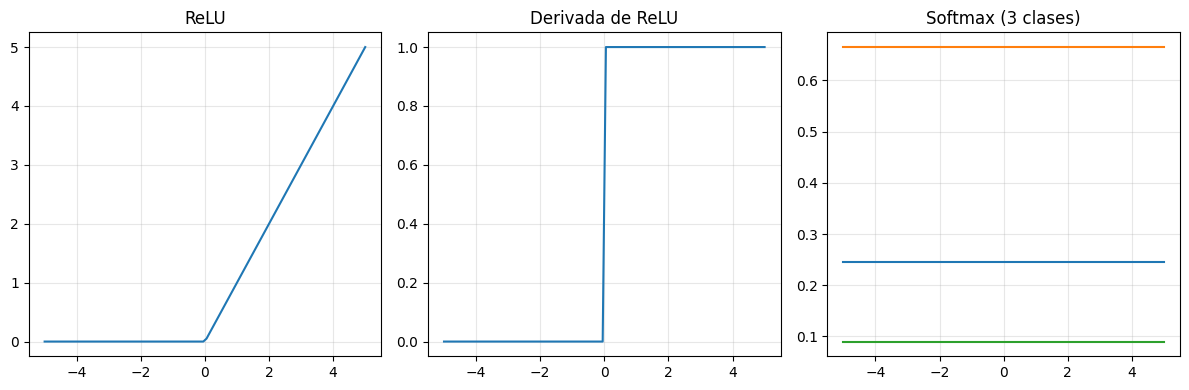

In [5]:
def relu(z):
    """
    Rectified Linear Unit: max(0, z)
    Si z > 0, devuelve z. Si z <= 0, devuelve 0.
    Es no lineal, simple y evita el problema del gradiente desvaneciente.
    """
    return np.maximum(0, z)

def relu_derivative(z):
    """
    Derivada de ReLU: 1 si z > 0, 0 si z <= 0
    Esto se usa en backpropagation para calcular gradientes.
    """
    return (z > 0).astype(float)

def softmax(z):
    """
    Softmax: convierte logits en probabilidades que suman 1.
    z puede ser cualquier número, softmax lo normaliza.
    Se resta el max para estabilidad numérica (evita overflow).
    """
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Imprimir ejemplos de activaciones, plot
x_samples = np.linspace(-5, 5, 100)
relu_samples = relu(x_samples)
relu_deriv_samples = relu_derivative(x_samples)
softmax_samples = softmax(np.array([x_samples, x_samples + 1, x_samples - 1]).T)  # 3 clases
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(x_samples, relu_samples)
plt.title("ReLU")
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 2)
plt.plot(x_samples, relu_deriv_samples)
plt.title("Derivada de ReLU")
plt.grid(True, alpha=0.3)
plt.subplot(1, 3, 3)
plt.plot(x_samples, softmax_samples)
plt.title("Softmax (3 clases)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

5. FUNCIÓN DE COSTO (ERROR CUADRÁTICO MEDIO)

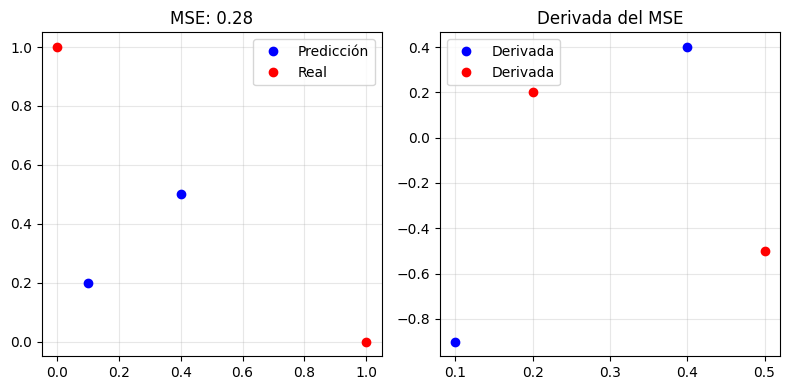

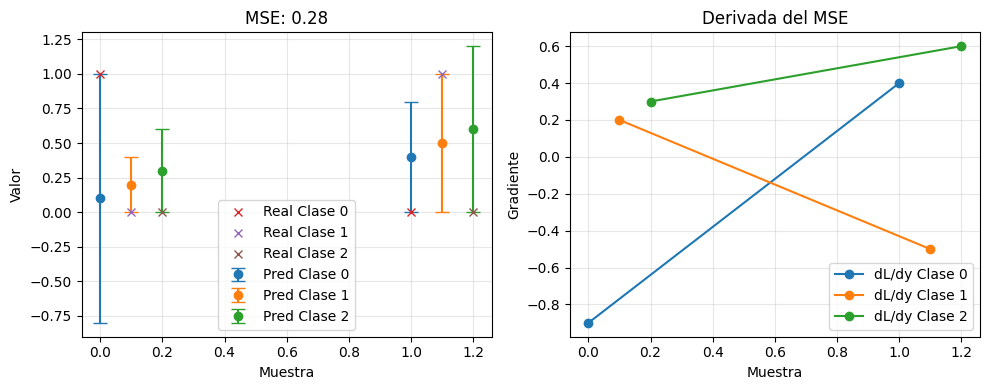

In [6]:


def mse_loss(y_pred, y_true_one_hot):
    """
    Error Cuadrático Medio: MSE = (1/n) * Σ(y_pred - y_true)²
    Mide qué tan lejos están las predicciones de los valores reales.
    """
    return np.mean((y_pred - y_true_one_hot) ** 2)

def mse_derivative(y_pred, y_true_one_hot):
    """
    Derivada del MSE respecto a y_pred: 2*(y_pred - y_true)/n
    Esto nos dice en qué dirección ajustar para reducir el error.
    """
    n = y_pred.shape[0]
    return 2 * (y_pred - y_true_one_hot) / n

# Ejemplo de datos para mse y su derivada
y_pred = np.array([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]])
y_true_one_hot = np.array([[1, 0, 0], [0, 1, 0]])

mse = mse_loss(y_pred, y_true_one_hot)
mse_deriv = mse_derivative(y_pred, y_true_one_hot)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(y_pred[:, 0], y_pred[:, 1], 'bo', label='Predicción')
plt.plot(y_true_one_hot[:, 0], y_true_one_hot[:, 1], 'ro', label='Real')
plt.title("MSE: {:.2f}".format(mse))
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(y_pred[:, 0], mse_deriv[:, 0], 'bo', label='Derivada')
plt.plot(y_pred[:, 1], mse_deriv[:, 1], 'ro', label='Derivada')
plt.title("Derivada del MSE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


########################################################
mse = mse_loss(y_pred, y_true_one_hot)
mse_deriv = mse_derivative(y_pred, y_true_one_hot)

# ===========================================
# Gráfica con barras de error
# ===========================================
plt.figure(figsize=(10, 4))

# Subplot 1: Predicciones vs reales con barras de error
plt.subplot(1, 2, 1)
x = np.arange(y_pred.shape[0])  # índice de cada muestra
for i in range(y_pred.shape[1]):  # cada clase
    plt.errorbar(x + i*0.1, y_pred[:, i],
                 yerr=np.abs(y_pred[:, i] - y_true_one_hot[:, i]),
                 fmt='o', capsize=5, label=f'Pred Clase {i}')

# Puntos reales
for i in range(y_true_one_hot.shape[1]):
    plt.plot(x + i*0.1, y_true_one_hot[:, i], 'x', label=f'Real Clase {i}')

plt.title(f"MSE: {mse:.2f}")
plt.xlabel("Muestra")
plt.ylabel("Valor")
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Derivada del MSE
plt.subplot(1, 2, 2)
for i in range(y_pred.shape[1]):
    plt.plot(x + i*0.1, mse_deriv[:, i], 'o-', label=f'dL/dy Clase {i}')

plt.title("Derivada del MSE")
plt.xlabel("Muestra")
plt.ylabel("Gradiente")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



6. ONE-HOT ENCODING, etiquetar Y

In [7]:


def one_hot(y, num_classes=10):
    """
    Convierte etiquetas [0, 5, 3, ...] en vectores one-hot:
    0 -> [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
    5 -> [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
    Necesario para comparar con la salida de softmax (10 probabilidades).
    """
    one_hot_matrix = np.zeros((len(y), num_classes))
    one_hot_matrix[np.arange(len(y)), y] = 1
    return one_hot_matrix

# ejemplo de uso
y_example = y_train[:5]  # primeras 5 etiquetas
y_one_hot_example = one_hot(y_example)
print("Etiquetas originales:", y_example)
print("One-hot encoded:\n", y_one_hot_example)



Etiquetas originales: [5 0 4 1 9]
One-hot encoded:
 [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]



7. FORWARD PROPAGATION (PASO HACIA ADELANTE)

In [8]:


def forward(X):
    """
    Calcula la salida de la red paso a paso.
    Guardamos valores intermedios (z1, a1, etc.) para usarlos en backprop.

    X: matriz de entrada (batch_size, 784)
    Entrada -> Capa oculta (ReLU) -> Salida (Softmax)

    Retorna: salida final y valores intermedios para backprop
    """
    # Capa 1: Entrada -> Oculta 1
    z1 = np.dot(X, w1) + b1      # Suma ponderada: X·W + b # que piensa la capa sin activación
    a1 = relu(z1)                # Activación ReLU         # que piensa la capa con activación

    # Capa 2: Oculta 1 -> Salida
    z2 = np.dot(a1, w2) + b2
    a2 = softmax(z2)             # Probabilidades para cada clase # que piensa toda la red neuronal

    # Guardamos todo en un diccionario para el backprop
    cache = {
        'z1': z1, 'a1': a1,
        'z2': z2, 'a2': a2,
        'X': X
    }

    return a2, cache



8. BACKWARD PROPAGATION (PASO HACIA ATRÁS)

In [9]:


def backward(cache, y_true_one_hot):
    """
    Calcula los gradientes de la función de costo respecto a cada parámetro.
    Usa la regla de la cadena (chain rule) del cálculo diferencial.

    Si C es el costo y queremos ∂C/∂w1:
    ∂C/∂w1 = ∂a2/∂z2 · ∂z2/∂a1 · ∂a1/∂z1 · ∂z1/∂w1

    Esto es lo que hace que las redes neuronales "aprendan".
    """
    global w1, w2, b1, b2

    # Extraemos valores del forward
    X = cache['X']
    a1, z1 = cache['a1'], cache['z1']
    a2, z2 = cache['a2'], cache['z2']

    m = X.shape[0]  # Tamaño del batch

    # --- Capa de salida ---
    # Derivada de MSE respecto a la salida softmax
    dz2 = mse_derivative(a2, y_true_one_hot)

    # Gradientes de pesos y sesgos de la capa de salida
    # Gradientes para w2 y b2
    # ∂C/∂w2 = a1^T · dz2  (transpuesta de activación anterior por error)
    dw2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)

    # --- Capa Oculta 1 ---
    # Propagamos el error hacia atrás: dz1 = dz2 · w2^T * relu'(z1)
    dz1 = np.dot(dz2, w2.T) * relu_derivative(z1)
    dw1 = np.dot(X.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)


    # Actualizamos pesos usando Gradient Descent (NO estocástico)
    # θ_nuevo = θ_viejo - learning_rate * gradiente
    w2 -= LEARNING_RATE * dw2
    b2 -= LEARNING_RATE * db2
    w1 -= LEARNING_RATE * dw1
    b1 -= LEARNING_RATE * db1

    return dw1, dw2  # Retornamos gradientes para monitoreo



9. ENTRENAMIENTO (GRADIENT DESCENT NO ESTOCÁSTICO)

In [10]:
def train_batch(X_batch, y_batch):
    """
    Entrena con un batch completo (Batch Gradient Descent).
    Calcula el gradiente promedio sobre todo el batch y actualiza una vez.
    """
    # Forward pass
    output, cache = forward(X_batch)

    # Convertir etiquetas a one-hot
    y_one_hot = one_hot(y_batch)

    # Calcular pérdida
    loss = mse_loss(output, y_one_hot)

    # Backward pass y actualización de pesos
    backward(cache, y_one_hot)

    # Calcular precisión
    predictions = np.argmax(output, axis=1)
    accuracy = np.mean(predictions == y_batch)

    return loss, accuracy

def predict(X):
    """Predice clases para nuevos datos."""
    output, _ = forward(X)
    return np.argmax(output, axis=1)

10. BUCLE DE ENTRENAMIENTO

In [11]:
print("\n" + "="*50)
print("INICIANDO ENTRENAMIENTO")
print("="*50)
print(f"Épocas: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Muestras de entrenamiento: {len(X_train)}")
print("="*50)

# Historial para graficar
train_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(EPOCHS):
    # Entrenamos con todo el dataset de una vez
    loss, acc = train_batch(X_train, y_train)

    # Evaluamos en test set (solo forward)
    test_preds = predict(X_test)
    test_acc = np.mean(test_preds == y_test)

    # Guardamos historial
    train_losses.append(loss)
    train_accuracies.append(acc)
    test_accuracies.append(test_acc)

    if (epoch + 1) % 50 == 0 or epoch == 0:
        print(f"Época {epoch+1:2d}/{EPOCHS} | "
            f"Pérdida: {loss:.4f} | "
            f"Train Acc: {acc:.4f} | "
            f"Test Acc: {test_acc:.4f}")


INICIANDO ENTRENAMIENTO
Épocas: 500
Learning Rate: 0.05
Muestras de entrenamiento: 60000
Época  1/500 | Pérdida: 0.0900 | Train Acc: 0.1027 | Test Acc: 0.1310
Época 50/500 | Pérdida: 0.0893 | Train Acc: 0.3142 | Test Acc: 0.3423
Época 100/500 | Pérdida: 0.0691 | Train Acc: 0.6447 | Test Acc: 0.6520
Época 150/500 | Pérdida: 0.0404 | Train Acc: 0.7776 | Test Acc: 0.7825
Época 200/500 | Pérdida: 0.0293 | Train Acc: 0.8303 | Test Acc: 0.8346
Época 250/500 | Pérdida: 0.0242 | Train Acc: 0.8550 | Test Acc: 0.8578
Época 300/500 | Pérdida: 0.0213 | Train Acc: 0.8696 | Test Acc: 0.8735
Época 350/500 | Pérdida: 0.0195 | Train Acc: 0.8788 | Test Acc: 0.8801
Época 400/500 | Pérdida: 0.0182 | Train Acc: 0.8851 | Test Acc: 0.8860
Época 450/500 | Pérdida: 0.0173 | Train Acc: 0.8900 | Test Acc: 0.8898
Época 500/500 | Pérdida: 0.0166 | Train Acc: 0.8937 | Test Acc: 0.8935


11. VISUALIZACIÓN DE RESULTADOS

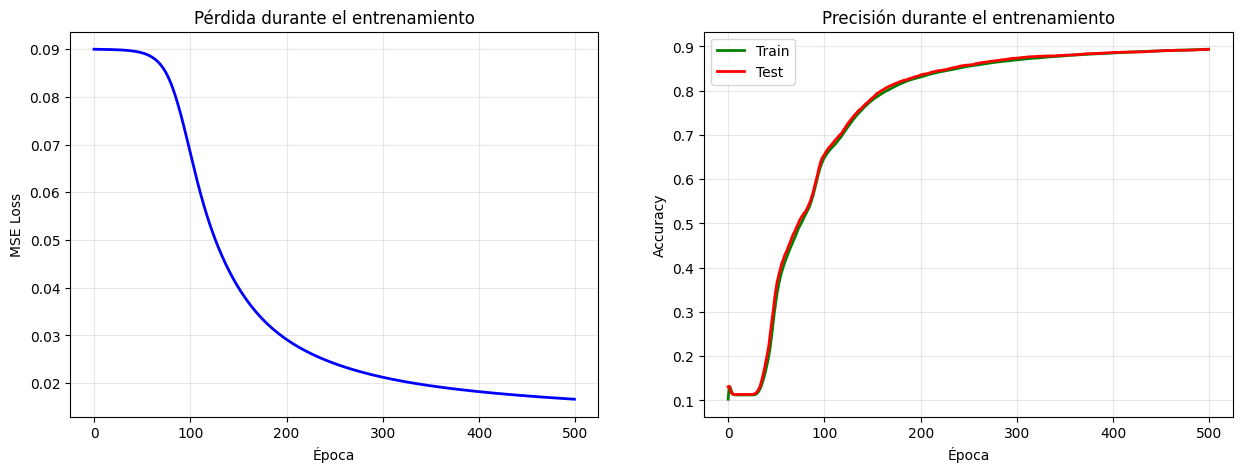

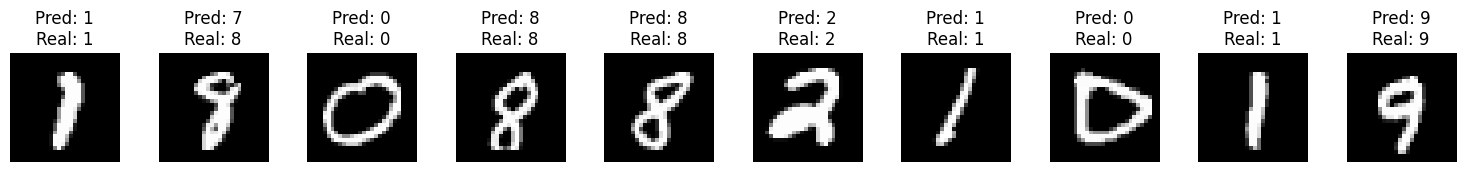

In [12]:


plt.figure(figsize=(15, 5))

# Gráfico 1: Pérdida
plt.subplot(1, 2, 1)
plt.plot(train_losses, 'b-', linewidth=2)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)

# Gráfico 2: Precisión
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, 'g-', label='Train', linewidth=2)
plt.plot(test_accuracies, 'r-', label='Test', linewidth=2)
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico 3: Predicciones de ejemplo
plt.figure(figsize=(15, 3))
# Mostrar 10 predicciones aleatorias del test set
sample_indices = np.random.choice(len(X_test), 10, replace=False)
predictions = predict(X_test[sample_indices])

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predictions[i]}\nReal: {y_test[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()



12. EVALUACIÓN FINAL


EVALUACIÓN FINAL
Precisión en entrenamiento: 0.8937
Precisión en test: 0.8935


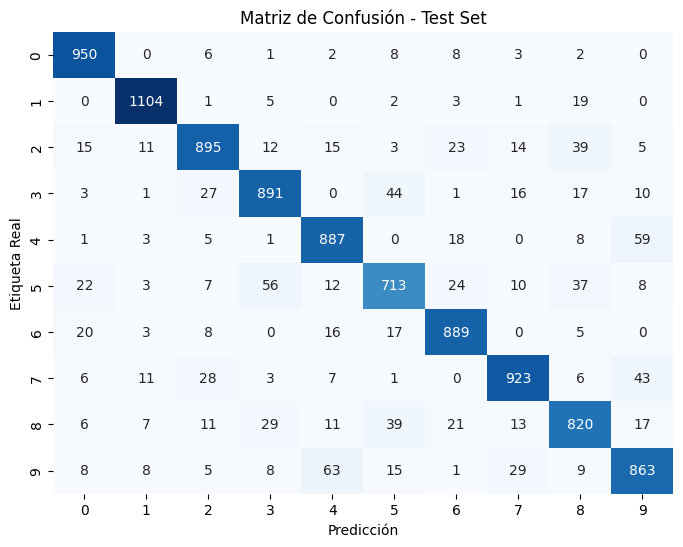


Top 10 errores más comunes:
  9→4: 63 veces (0.63%)
  4→9: 59 veces (0.59%)
  5→3: 56 veces (0.56%)
  3→5: 44 veces (0.44%)
  7→9: 43 veces (0.43%)
  2→8: 39 veces (0.39%)
  8→5: 39 veces (0.39%)
  5→8: 37 veces (0.37%)
  9→7: 29 veces (0.29%)
  8→3: 29 veces (0.29%)

¡Entrenamiento completado!


In [13]:
print("\n" + "="*50)
print("EVALUACIÓN FINAL")
print("="*50)


# Precisión final
final_train_preds = predict(X_train)
final_test_preds = predict(X_test)

train_acc = np.mean(final_train_preds == y_train)
test_acc = np.mean(final_test_preds == y_test)

print(f"Precisión en entrenamiento: {train_acc:.4f}")
print(f"Precisión en test: {test_acc:.4f}")

# -------------------------------
# Matriz de confusión
# -------------------------------
cm = confusion_matrix(y_test, final_test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de Confusión - Test Set")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta Real")
plt.show()

# -------------------------------
# Top 10 errores más comunes
# -------------------------------
from collections import Counter
errors = Counter()
for i in range(len(y_test)):
    if final_test_preds[i] != y_test[i]:
        errors[f"{y_test[i]}→{final_test_preds[i]}"] += 1

print("\nTop 10 errores más comunes:")
for error, count in errors.most_common(10):
    porcentaje = count / len(y_test) * 100
    print(f"  {error}: {count} veces ({porcentaje:.2f}%)")

print("\n¡Entrenamiento completado!")

In [15]:
def guardar_modelo(ruta="modelo_mnist.npz"):
    global w1, b1, w2, b2

    np.savez(ruta,
             w1=w1, b1=b1,
             w2=w2, b2=b2
            )

    print("Modelo guardado correctamente.")

def cargar_modelo(ruta="modelo_mnist.npz"):
    global w1, b1, w2, b2

    datos = np.load(ruta)

    w1 = datos["w1"]
    b1 = datos["b1"]
    w2 = datos["w2"]
    b2 = datos["b2"]

    print("Modelo cargado correctamente.")

guardar_modelo()


Modelo guardado correctamente.


In [17]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


w1, b1, w2, b2, w3, b3 = (
    None,
    None,
    None,
    None,
    None,
    None,
)

def cargar_imagen(path: str, invertir=False):
    img = Image.open(path)
    img = img.convert("L")  # "L" = grayscale
    img = img.resize((28, 28))

    # Convertir a array numpy
    img_array = np.array(img)

    # Normalizar (0-255 → 0-1)
    img_array = img_array / 255.0

    if invertir:
        img_array = 1.0 - img_array

    img_vector = img_array.flatten()

    # Agregar dimensión batch (1, 784)
    img_vector = img_vector.reshape(1, -1)

    return img_vector


def mostrar_imagen(vector):
    # Quitar dimensión batch si existe
    if vector.shape[0] == 1:
        vector = vector.reshape(-1)

    # Volver a 28x28
    img = vector.reshape(28, 28)

    # Mostrar imagen
    plt.imshow(img, cmap="gray")
    plt.title("Imagen procesada 28x28")
    plt.axis("off")
    plt.show()

cargar_modelo()
x = cargar_imagen("ocho.jpg", True)
mostrar_imagen(x)
pred, _ = forward(x)

print("Probabilidades:", pred)
print("Predicción:", np.argmax(pred))

Modelo cargado correctamente.


FileNotFoundError: [Errno 2] No such file or directory: 'ocho.jpg'